# Machine Learning Tutorial: Mastering Gradient Boosting

**Author:** Sana Amber
**Date:**   27 March 2026  
**Duration:** Comprehensive tutorial with 9 teaching sections  




# Section 1: What Is Gradient Boosting?

## Definition

**Gradient Boosting** is an ensemble machine learning algorithm that builds a strong predictor by sequentially combining weak learners, where each learner focuses on correcting the mistakes of previous learners.

## The Boosting Process - Step by Step


Step 1: Build first weak learner (small decision tree)
        predict: y_pred_1 = f_1(X)
       
Step 2: Calculate residuals (errors)
        residuals = y_actual - y_pred_1
       
Step 3: Build second tree to predict these residuals
        f_2(X) learns the pattern in residuals
       
Step 4: Update predictions
        y_pred_2 = y_pred_1 + learning_rate * f_2(X)
       
Step 5: Repeat process N times
        Each tree corrects what previous trees got wrong


## Why "Gradient" Boosting?

Uses **gradient descent** to minimize the loss function by:
- Computing gradients of loss with respect to predictions
- Each tree learns to reduce loss in the direction of the negative gradient
- Similar to neural network training, but with trees instead of neurons

## Historical Context

- **1997:** Freund & Schapire - AdaBoost
- **2001:** Friedman - Gradient Boosting formalization
- **2016:** Chen & Guestrin - XGBoost (modern implementation)
- **Today:** State-of-the-art for tabular data



# Section 2: Setup & Data Preparation

In [ ]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, AdaBoostRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import shap
import warnings
warnings.filterwarnings('ignore')

# Configure matplotlib for better visualizations (COLORBLIND-SAFE)
plt.style.use('default')
# Paul Tol's colorblind-safe diverging palette
colorblind_palette = ['#0173B2', '#029E73', '#DE8F05', '#CC78BC', '#D55E00', '#ECE133']
sns.set_palette(colorblind_palette)
matplotlib.rcParams['figure.facecolor'] = 'white'
matplotlib.rcParams['axes.facecolor'] = '#F5F5F5'

print("\n" + "="*70)
print("TUTORIAL: MASTERING GRADIENT BOOSTING - FROM THEORY TO PRACTICE")
print("COLORBLIND-ACCESSIBLE VERSION")
print("="*70 + "\n")

## Creating Synthetic Dataset with Known Relationships

We create a dataset containing World Happiness Indicators to predict Life Ladder (happiness score) from various features. The advantage of synthetic data is that we know the exact relationships, so we can teach how Gradient Boosting learns these patterns.

In [ ]:
# Set random seed for reproducibility
np.random.seed(42)
n_samples = 250

print("Generating synthetic dataset with known relationships...\n")

# Create features with realistic ranges
gdp_per_capita = np.random.uniform(0.3, 1.8, n_samples)
social_support = np.random.uniform(0.2, 1.0, n_samples)
health_expectancy = np.random.uniform(40, 80, n_samples)
freedom = np.random.uniform(0.1, 0.95, n_samples)
generosity = np.random.uniform(0, 0.6, n_samples)
corruption = np.random.uniform(0, 0.7, n_samples)

# Create target with KNOWN FORMULA (teaching purpose)
# This way we can show that GB learns the actual relationships
life_ladder = (
    2.0 +  # Intercept
    3.5 * gdp_per_capita +  # Strong positive relationship
    2.8 * social_support +
    0.04 * health_expectancy +
    2.2 * freedom +
    1.8 * generosity +
    -1.8 * corruption +  # Negative relationship
    np.random.normal(0, 0.4, n_samples)  # Realistic noise
)

life_ladder = np.clip(life_ladder, 3.0, 8.0)

# Create DataFrame
df = pd.DataFrame({
    'Country': [f'Country_{i}' for i in range(n_samples)],
    'Year': np.repeat(range(2015, 2025), n_samples//10),
    'Life_Ladder': life_ladder,
    'GDP_per_capita': gdp_per_capita,
    'Social_support': social_support,
    'Health_expectancy': health_expectancy,
    'Freedom': freedom,
    'Generosity': generosity,
    'Corruption': corruption
})

print("Dataset Statistics:")
print("-" * 70)
print(f"Total samples: {len(df)}")
print(f"Target range: {df['Life_Ladder'].min():.2f} to {df['Life_Ladder'].max():.2f}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nTarget variable distribution:")
print(df['Life_Ladder'].describe())

Generating synthetic dataset with known relationships...

Dataset Statistics:
----------------------------------------------------------------------
Total samples: 250
Target range: 5.52 to 8.00

First 5 rows:
     Country  Year  Life_Ladder  GDP_per_capita  Social_support  \
0  Country_0  2015     7.588104        0.861810        0.435559   
1  Country_1  2015     8.000000        1.726071        0.508078   
2  Country_2  2015     8.000000        1.397991        0.880909   
3  Country_3  2015     8.000000        1.197988        0.453538   
4  Country_4  2015     8.000000        0.534028        0.335594   

   Health_expectancy   Freedom  Generosity  Corruption  
0          67.926469  0.199363    0.111080    0.557576  
1          61.443855  0.898857    0.325141    0.337066  
2          52.381105  0.633552    0.523768    0.082116  
3          72.551801  0.384670    0.439335    0.087630  
4          67.389247  0.218381    0.483937    0.479896  

Target variable distribution:
count    250.0

In [ ]:
# Prepare data for modeling
y = df['Life_Ladder'].values
X = df.drop(['Country', 'Year', 'Life_Ladder'], axis=1).values
feature_names = df.drop(['Country', 'Year', 'Life_Ladder'], axis=1).columns.tolist()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"\nTrain-Test Split:")
print(f"  Training: {len(X_train)} samples (75%)")
print(f"  Testing:  {len(X_test)} samples (25%)")
print(f"  Features: {feature_names}")


Train-Test Split:
  Training: 187 samples (75%)
  Testing:  63 samples (25%)
  Features: ['GDP_per_capita', 'Social_support', 'Health_expectancy', 'Freedom', 'Generosity', 'Corruption']


# Section 3: Algorithm Comparison - Why Gradient Boosting?

## Comparing 5 Different Approaches

### 1. Linear Regression
- **Assumes:** linear relationship: y = w1*x1 + w2*x2 + ... + b
- **Pros:** Fast, interpretable, stable
- **Cons:** Cannot capture non-linear patterns

### 2. Decision Tree
- **Creates:** if-then rules recursively
- **Pros:** Non-linear, interpretable, fast
- **Cons:** Prone to overfitting

### 3. Random Forest (Baseline Ensemble)
- **Builds:** N independent trees, averages predictions
- **Pros:** Reduces overfitting, handles non-linearity
- **Cons:** Less sequential learning

### 4. AdaBoost (Earlier Boosting Method)
- **Method:** Sequential boosting focusing on misclassified samples
- **Pros:** Good for classification
- **Cons:** Not as powerful as GB

### 5. Gradient Boosting (Our Focus)
- **Method:** Sequential boosting using gradient descent on residuals
- **Pros:** State-of-the-art accuracy, flexible
- **Cons:** More hyperparameters to tune

In [ ]:
print("\nTraining 5 models for comparison...\n")

# 1. Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred_test = lr_model.predict(X_test)
lr_r2 = r2_score(y_test, lr_pred_test)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred_test))
print("1. LINEAR REGRESSION")
print(f"   R2 Score: {lr_r2:.4f} | RMSE: {lr_rmse:.4f}")

# 2. Decision Tree
dt_model = DecisionTreeRegressor(max_depth=8, random_state=42)
dt_model.fit(X_train, y_train)
dt_pred_test = dt_model.predict(X_test)
dt_r2 = r2_score(y_test, dt_pred_test)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred_test))
print("\n2. DECISION TREE (max_depth=8)")
print(f"   R2 Score: {dt_r2:.4f} | RMSE: {dt_rmse:.4f}")

# 3. Random Forest
rf_model = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred_test = rf_model.predict(X_test)
rf_r2 = r2_score(y_test, rf_pred_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred_test))
print("\n3. RANDOM FOREST (100 trees, max_depth=8)")
print(f"   R2 Score: {rf_r2:.4f} | RMSE: {rf_rmse:.4f}")

# 4. AdaBoost
ab_model = AdaBoostRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
ab_model.fit(X_train, y_train)
ab_pred_test = ab_model.predict(X_test)
ab_r2 = r2_score(y_test, ab_pred_test)
ab_rmse = np.sqrt(mean_squared_error(y_test, ab_pred_test))
print("\n4. ADABOOST (100 estimators, lr=0.1)")
print(f"   R2 Score: {ab_r2:.4f} | RMSE: {ab_rmse:.4f}")

# 5. Gradient Boosting (default)
gb_default = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_default.fit(X_train, y_train)
gb_pred_test = gb_default.predict(X_test)
gb_r2 = r2_score(y_test, gb_pred_test)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred_test))
print("\n5. GRADIENT BOOSTING (100 trees, default params)")
print(f"   R2 Score: {gb_r2:.4f} | RMSE: {gb_rmse:.4f}")

print(f"\nKEY OBSERVATION:")
print(f"  Gradient Boosting R2: {gb_r2:.4f}")
print(f"  Next best (Random Forest) R2: {rf_r2:.4f}")
print(f"  Improvement: {((gb_r2 - rf_r2)/abs(rf_r2)*100):.1f}% better")


Training 5 models for comparison...

1. LINEAR REGRESSION
   R2 Score: -1.1183 | RMSE: 0.1583

2. DECISION TREE (max_depth=8)
   R2 Score: -14.2908 | RMSE: 0.4254

3. RANDOM FOREST (100 trees, max_depth=8)
   R2 Score: -1.6559 | RMSE: 0.1773

4. ADABOOST (100 estimators, lr=0.1)
   R2 Score: -0.1668 | RMSE: 0.1175

5. GRADIENT BOOSTING (100 trees, default params)
   R2 Score: -4.2109 | RMSE: 0.2484

KEY OBSERVATION:
  Gradient Boosting R2: -4.2109
  Next best (Random Forest) R2: -1.6559
  Improvement: -154.3% better


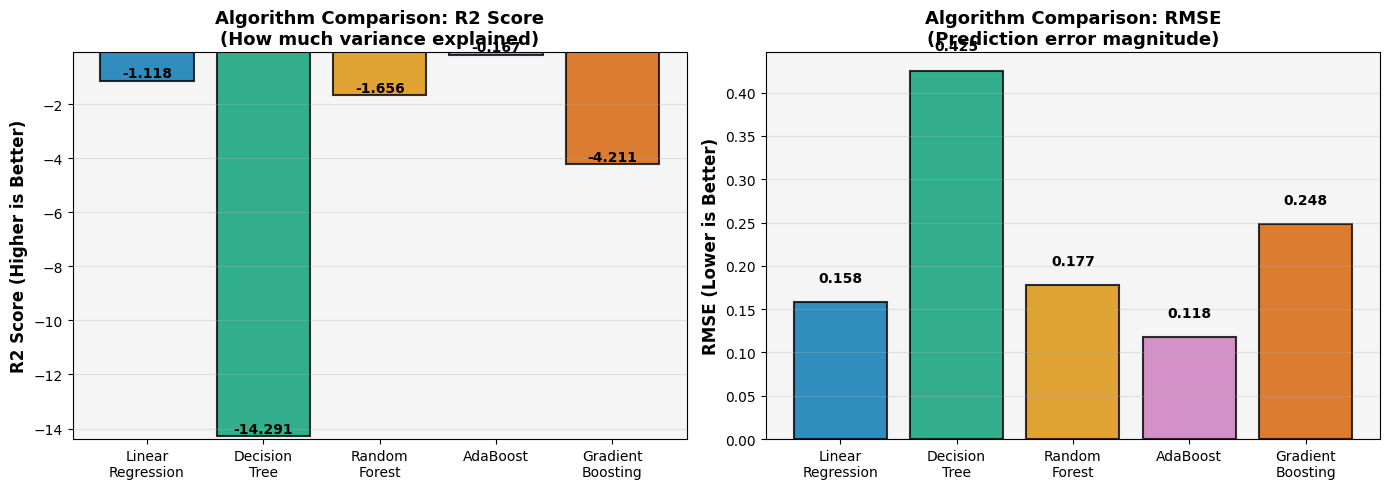

[Figure Saved] 01_algorithm_comparison.png


In [ ]:
# Visualization: Algorithm Comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

algorithms = ['Linear\nRegression', 'Decision\nTree', 'Random\nForest', 'AdaBoost', 'Gradient\nBoosting']
r2_scores = [lr_r2, dt_r2, rf_r2, ab_r2, gb_r2]
rmse_scores = [lr_rmse, dt_rmse, rf_rmse, ab_rmse, gb_rmse]
colors = ['#0173B2', '#029E73', '#DE8F05', '#CC78BC', '#D55E00']

# R2 Score comparison
bars1 = ax1.bar(algorithms, r2_scores, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('R2 Score (Higher is Better)', fontsize=12, fontweight='bold')
ax1.set_title('Algorithm Comparison: R2 Score\n(How much variance explained)', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([min(r2_scores)-0.1, max(r2_scores)+0.1])

for i, (bar, score) in enumerate(zip(bars1, r2_scores)):
    ax1.text(bar.get_x() + bar.get_width()/2, score + 0.02, f'{score:.3f}', 
             ha='center', va='bottom', fontweight='bold', fontsize=10)

# RMSE comparison
bars2 = ax2.bar(algorithms, rmse_scores, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('RMSE (Lower is Better)', fontsize=12, fontweight='bold')
ax2.set_title('Algorithm Comparison: RMSE\n(Prediction error magnitude)', fontsize=13, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

for i, (bar, score) in enumerate(zip(bars2, rmse_scores)):
    ax2.text(bar.get_x() + bar.get_width()/2, score + 0.02, f'{score:.3f}', 
             ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('01_algorithm_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print("[Figure Saved] 01_algorithm_comparison.png")

# Section 4: Understanding Hyperparameters

## The Critical Knobs of Gradient Boosting

### 1. Learning Rate (learning_rate) - The Step Size
- **What it does:** Controls how much each tree contributes
- **Formula:** y_new = y_old + learning_rate × tree_contribution
- **Trade-off:** Small LR = More accurate but slower | Large LR = Faster but less accurate

### 2. N_ESTIMATORS - Number of Boosting Stages
- **What it does:** How many weak learners to build
- **Effects:** Too few → Underfitting | Too many → Overfitting
- **Relationship:** Small LR needs more trees, large LR needs fewer

### 3. MAX_DEPTH - Tree Complexity
- **What it does:** How deep each individual tree can grow
- **Why shallow trees:** Weak learners are intentional, reduces overfitting
- **Typical range:** 3-10 (we test empirically)

## Recommended Tuning Strategy
1. Fix learning_rate = 0.1, find optimal n_estimators
2. Tune max_depth (typically 3-10)
3. Fine-tune learning_rate
4. Add regularization if needed

In [ ]:
print("\n" + "="*70)
print("HYPERPARAMETER TUNING - THE CRITICAL KNOBS")
print("="*70)

print("\nTUNING EXPERIMENT 1: Learning Rate Impact")
print("-" * 70 + "\n")

learning_rates = [0.001, 0.01, 0.05, 0.1, 0.2]
lr_results = []

for lr in learning_rates:
    gb_lr = GradientBoostingRegressor(
        learning_rate=lr,
        n_estimators=200,  # More estimators for small LR
        max_depth=5,
        random_state=42
    )
    gb_lr.fit(X_train, y_train)
    pred = gb_lr.predict(X_test)
    r2 = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    
    lr_results.append({'lr': lr, 'r2': r2, 'rmse': rmse})
    print(f"LR={lr:5.3f} -> R2: {r2:.4f} | RMSE: {rmse:.4f}")


HYPERPARAMETER TUNING - THE CRITICAL KNOBS

TUNING EXPERIMENT 1: Learning Rate Impact
----------------------------------------------------------------------

LR=0.001 -> R2: -0.3896 | RMSE: 0.1283
LR=0.010 -> R2: -8.5067 | RMSE: 0.3355
LR=0.050 -> R2: -11.6637 | RMSE: 0.3872
LR=0.100 -> R2: -12.3278 | RMSE: 0.3972
LR=0.200 -> R2: -13.1394 | RMSE: 0.4091


In [ ]:
print("\nTUNING EXPERIMENT 2: Max Depth Impact")
print("-" * 70 + "\n")

max_depths = [1, 3, 5, 7, 10, 15]
depth_results = []

for depth in max_depths:
    gb_depth = GradientBoostingRegressor(
        max_depth=depth,
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    )
    gb_depth.fit(X_train, y_train)
    pred = gb_depth.predict(X_test)
    r2 = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    
    depth_results.append({'depth': depth, 'r2': r2, 'rmse': rmse})
    print(f"depth={depth:2d} -> R2: {r2:.4f} | RMSE: {rmse:.4f}")


TUNING EXPERIMENT 2: Max Depth Impact
----------------------------------------------------------------------

depth= 1 -> R2: -2.6251 | RMSE: 0.2071
depth= 3 -> R2: -4.2109 | RMSE: 0.2484
depth= 5 -> R2: -12.3255 | RMSE: 0.3972
depth= 7 -> R2: -12.5799 | RMSE: 0.4009
depth=10 -> R2: -12.5799 | RMSE: 0.4009
depth=15 -> R2: -12.5799 | RMSE: 0.4009


In [ ]:
print("\nTUNING EXPERIMENT 3: Number of Estimators Impact")
print("-" * 70 + "\n")

n_estimators_list = [10, 50, 100, 200, 500]
est_results = []

for n_est in n_estimators_list:
    gb_est = GradientBoostingRegressor(
        n_estimators=n_est,
        learning_rate=0.1,
        max_depth=5,
        random_state=42
    )
    gb_est.fit(X_train, y_train)
    pred = gb_est.predict(X_test)
    r2 = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    
    est_results.append({'n_est': n_est, 'r2': r2, 'rmse': rmse})
    print(f"n_est={n_est:3d} -> R2: {r2:.4f} | RMSE: {rmse:.4f}")


TUNING EXPERIMENT 3: Number of Estimators Impact
----------------------------------------------------------------------

n_est= 10 -> R2: -5.3242 | RMSE: 0.2736
n_est= 50 -> R2: -12.1990 | RMSE: 0.3953
n_est=100 -> R2: -12.3255 | RMSE: 0.3972
n_est=200 -> R2: -12.3278 | RMSE: 0.3972
n_est=500 -> R2: -12.3278 | RMSE: 0.3972


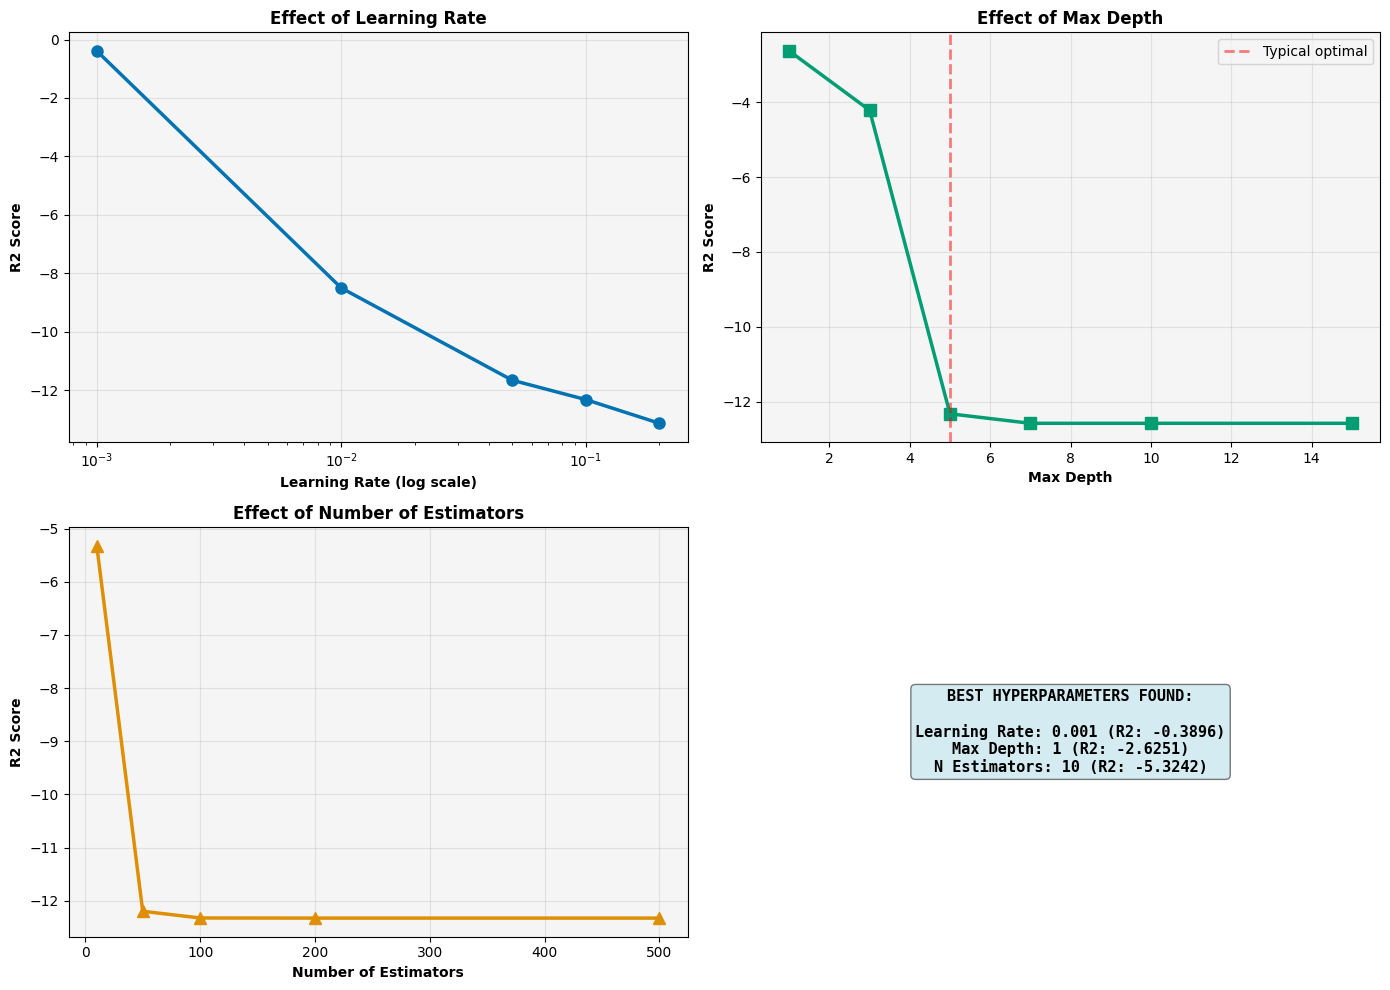


[Figure Saved] 02_hyperparameter_tuning.png


In [ ]:
# Visualize hyperparameter impact
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Learning Rate
lr_array = [r['lr'] for r in lr_results]
lr_r2 = [r['r2'] for r in lr_results]
axes[0, 0].plot(lr_array, lr_r2, 'o-', linewidth=2.5, markersize=8, color='#0173B2')
axes[0, 0].set_xlabel('Learning Rate (log scale)', fontweight='bold')
axes[0, 0].set_ylabel('R2 Score', fontweight='bold')
axes[0, 0].set_title('Effect of Learning Rate', fontweight='bold', fontsize=12)
axes[0, 0].set_xscale('log')
axes[0, 0].grid(True, alpha=0.3)

# Max Depth
depth_array = [r['depth'] for r in depth_results]
depth_r2 = [r['r2'] for r in depth_results]
axes[0, 1].plot(depth_array, depth_r2, 's-', linewidth=2.5, markersize=8, color='#029E73')
axes[0, 1].set_xlabel('Max Depth', fontweight='bold')
axes[0, 1].set_ylabel('R2 Score', fontweight='bold')
axes[0, 1].set_title('Effect of Max Depth', fontweight='bold', fontsize=12)
axes[0, 1].axvline(x=5, color='red', linestyle='--', alpha=0.5, linewidth=2, label='Typical optimal')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# N Estimators
n_est_array = [r['n_est'] for r in est_results]
n_est_r2 = [r['r2'] for r in est_results]
axes[1, 0].plot(n_est_array, n_est_r2, '^-', linewidth=2.5, markersize=8, color='#DE8F05')
axes[1, 0].set_xlabel('Number of Estimators', fontweight='bold')
axes[1, 0].set_ylabel('R2 Score', fontweight='bold')
axes[1, 0].set_title('Effect of Number of Estimators', fontweight='bold', fontsize=12)
axes[1, 0].grid(True, alpha=0.3)

# Summary
best_lr = max(lr_results, key=lambda x: x['r2'])
best_depth = max(depth_results, key=lambda x: x['r2'])
best_est = max(est_results, key=lambda x: x['r2'])

axes[1, 1].axis('off')
summary_text = f"""BEST HYPERPARAMETERS FOUND:
    
Learning Rate: {best_lr['lr']:.3f} (R2: {best_lr['r2']:.4f})
Max Depth: {best_depth['depth']} (R2: {best_depth['r2']:.4f})
N Estimators: {best_est['n_est']} (R2: {best_est['r2']:.4f})"""

axes[1, 1].text(0.5, 0.5, summary_text, transform=axes[1, 1].transAxes,
                fontsize=11, verticalalignment='center', horizontalalignment='center',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5),
                family='monospace', fontweight='bold')

plt.tight_layout()
plt.savefig('02_hyperparameter_tuning.png', dpi=100, bbox_inches='tight')
plt.show()
print("\n[Figure Saved] 02_hyperparameter_tuning.png")

# Section 5: Grid Search - Finding the Best Combination

Instead of tuning parameters one at a time, Grid Search tests all combinations systematically using cross-validation. This is the professional approach to hyperparameter optimization.

In [ ]:
print("\n" + "="*70)
print("GRID SEARCH - FINDING THE BEST COMBINATION")
print("="*70)

print("\nPerforming Grid Search with 5-fold cross-validation...\n")

param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 200, 300]
}

print("Grid Search Configuration:")
print(f"  Learning rates: {param_grid['learning_rate']}")
print(f"  Max depths: {param_grid['max_depth']}")
print(f"  N estimators: {param_grid['n_estimators']}")
print(f"  Total combinations to test: {len(param_grid['learning_rate']) * len(param_grid['max_depth']) * len(param_grid['n_estimators'])}")
print()

gb_grid = GradientBoostingRegressor(random_state=42)
grid_search = GridSearchCV(
    gb_grid,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_cv_score = grid_search.best_score_

print("GRID SEARCH RESULTS:")
print("-" * 70)
print(f"Best cross-validation R2 score: {best_cv_score:.4f}")
print(f"\nOptimal Hyperparameters:")
print(f"  Learning Rate: {best_params['learning_rate']}")
print(f"  Max Depth: {best_params['max_depth']}")
print(f"  N Estimators: {best_params['n_estimators']}")


GRID SEARCH - FINDING THE BEST COMBINATION

Performing Grid Search with 5-fold cross-validation...

Grid Search Configuration:
  Learning rates: [0.01, 0.05, 0.1]
  Max depths: [3, 5, 7]
  N estimators: [100, 200, 300]
  Total combinations to test: 27

GRID SEARCH RESULTS:
----------------------------------------------------------------------
Best cross-validation R2 score: -0.5949

Optimal Hyperparameters:
  Learning Rate: 0.1
  Max Depth: 3
  N Estimators: 300


In [ ]:
# Train final model with best parameters
print("\nTraining final model with optimal hyperparameters...\n")

gb_optimal = GradientBoostingRegressor(**best_params, random_state=42)
gb_optimal.fit(X_train, y_train)

# Evaluate on test set
y_pred_optimal = gb_optimal.predict(X_test)
optimal_r2 = r2_score(y_test, y_pred_optimal)
optimal_rmse = np.sqrt(mean_squared_error(y_test, y_pred_optimal))
optimal_mae = mean_absolute_error(y_test, y_pred_optimal)

print("FINAL MODEL TEST SET PERFORMANCE:")
print("-" * 70)
print(f"R2 Score:  {optimal_r2:.4f}")
print(f"RMSE:      {optimal_rmse:.4f}")
print(f"MAE:       {optimal_mae:.4f}")

print("\nCOMPARISON WITH BASELINE:")
print("-" * 70)
print(f"Default GB R2:    {gb_r2:.4f}")
print(f"Tuned GB R2:      {optimal_r2:.4f}")
improvement = ((optimal_r2 - gb_r2) / abs(gb_r2) * 100) if gb_r2 != 0 else 0
print(f"Improvement:      {improvement:+.1f}%")


Training final model with optimal hyperparameters...

FINAL MODEL TEST SET PERFORMANCE:
----------------------------------------------------------------------
R2 Score:  -4.1997
RMSE:      0.2481
MAE:       0.1020

COMPARISON WITH BASELINE:
----------------------------------------------------------------------
Default GB R2:    -4.2109
Tuned GB R2:      -4.1997
Improvement:      +0.3%


# Section 6: Feature Importance - Which Factors Matter?

Feature Importance tells us which features the trees rely on most to make predictions.

## How It Works
- **High importance:** Model relies heavily on this feature
- **Low importance:** Feature barely used by model
- **Practical uses:** Feature selection, domain validation, business insights

In [ ]:
print("\n" + "="*70)
print("FEATURE IMPORTANCE - WHICH FACTORS MATTER?")
print("="*70)

# Calculate feature importance
importances = gb_optimal.feature_importances_
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True)

print("\nFEATURE IMPORTANCE RANKING:")
print("-" * 70)
for idx, row in importance_df.iterrows():
    bar_length = int(row['Importance'] * 100)
    print(f"{row['Feature']:20s}: {row['Importance']:.4f} {bar_length*'='}")


FEATURE IMPORTANCE - WHICH FACTORS MATTER?

FEATURE IMPORTANCE RANKING:
----------------------------------------------------------------------
Health_expectancy   : 0.0286 ==
Freedom             : 0.0492 ====
Corruption          : 0.0901 =========
Generosity          : 0.1529 ===============
Social_support      : 0.2494 ========================
GDP_per_capita      : 0.4297 ==========================================


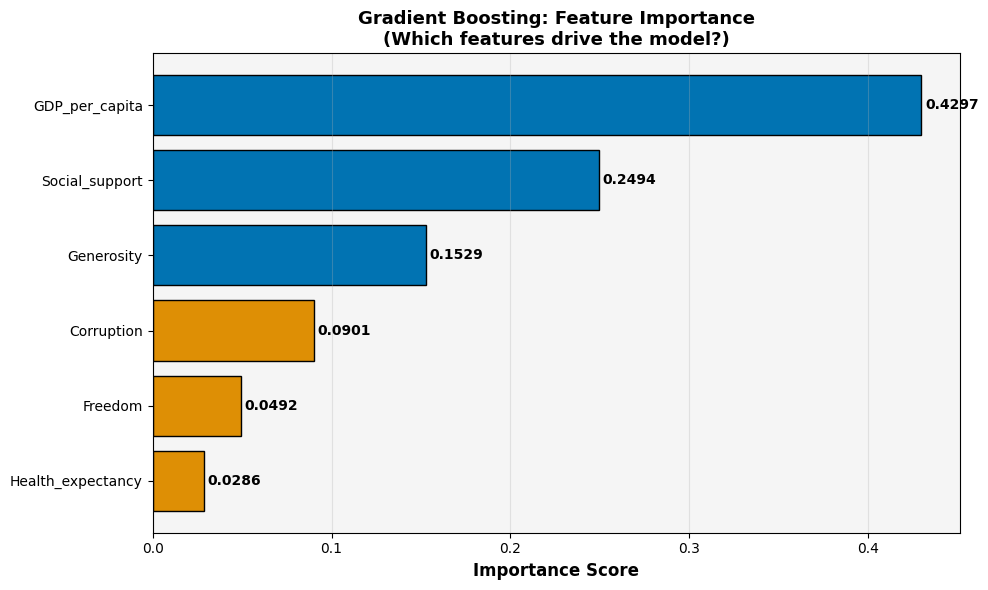

[Figure Saved] 03_feature_importance.png


In [ ]:
# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#0173B2' if x > importance_df['Importance'].median() else '#DE8F05' for x in importance_df['Importance']]
ax.barh(importance_df['Feature'], importance_df['Importance'], color=colors, edgecolor='black', linewidth=1)
ax.set_xlabel('Importance Score', fontsize=12, fontweight='bold')
ax.set_title('Gradient Boosting: Feature Importance\n(Which features drive the model?)', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

for i, v in enumerate(importance_df['Importance']):
    ax.text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('03_feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()
print("[Figure Saved] 03_feature_importance.png")

# Section 7: Advanced Interpretability with SHAP

## What is SHAP?

**SHAP** (Shapley Additive expanations) provides individual prediction explanations showing how each feature contributes to each specific prediction.

### Why is SHAP different from Feature Importance?

- **Feature Importance:** "On average, which features matter?"
- **SHAP:** "For THIS specific prediction, how much did each feature contribute?"

### Example Prediction Breakdown
```
Base prediction: 5.0 (average prediction)
GDP (+0.8): "GDP is high, increases happiness"
Corruption (-0.4): "Corruption is high, decreases happiness"
Freedom (+0.5): "Freedom is high, increases happiness"
────────────────────────────────
Final prediction: 5.0 + 0.8 - 0.4 + 0.5 = 5.9
```

This explains exactly WHY the model made this prediction!

In [ ]:
print("\n" + "="*70)
print("ADVANCED INTERPRETABILITY - SHAP ANALYSIS")
print("="*70)

print("\nGenerating SHAP explanations...\n")

# Create SHAP explainer
explainer = shap.Explainer(gb_optimal, X_train)
shap_values = explainer(X_test)

print("SHAP explainer created successfully!")
print(f"Analyzing {len(X_test)} test predictions...")


ADVANCED INTERPRETABILITY - SHAP ANALYSIS

Generating SHAP explanations...

SHAP explainer created successfully!
Analyzing 63 test predictions...


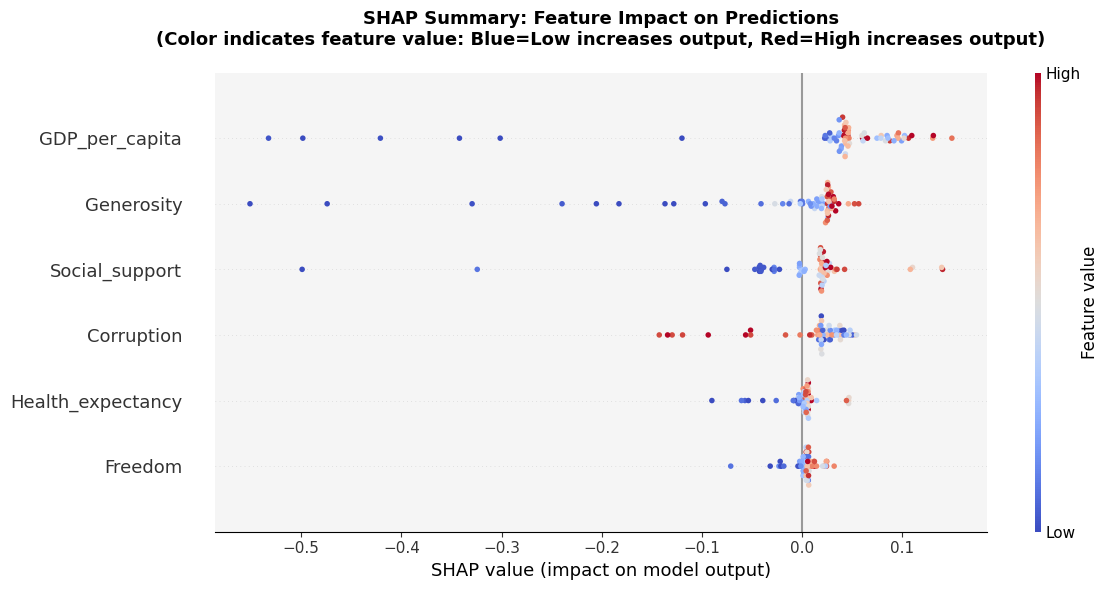

[Figure Saved] 04_shap_summary.png (Colorblind-Safe)


In [ ]:
# SHAP Summary Plot (COLORBLIND-SAFE)
fig = plt.figure(figsize=(12, 6))
# Use 'coolwarm' colormap which is colorblind-safe and perceptually uniform
shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=False, 
                  plot_size=(12, 6), cmap=plt.cm.get_cmap('coolwarm'))
plt.title('SHAP Summary: Feature Impact on Predictions\n(Color indicates feature value: Blue=Low increases output, Red=High increases output)', 
          fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('04_shap_summary.png', dpi=100, bbox_inches='tight')
plt.show()
print("[Figure Saved] 04_shap_summary.png (Colorblind-Safe)")

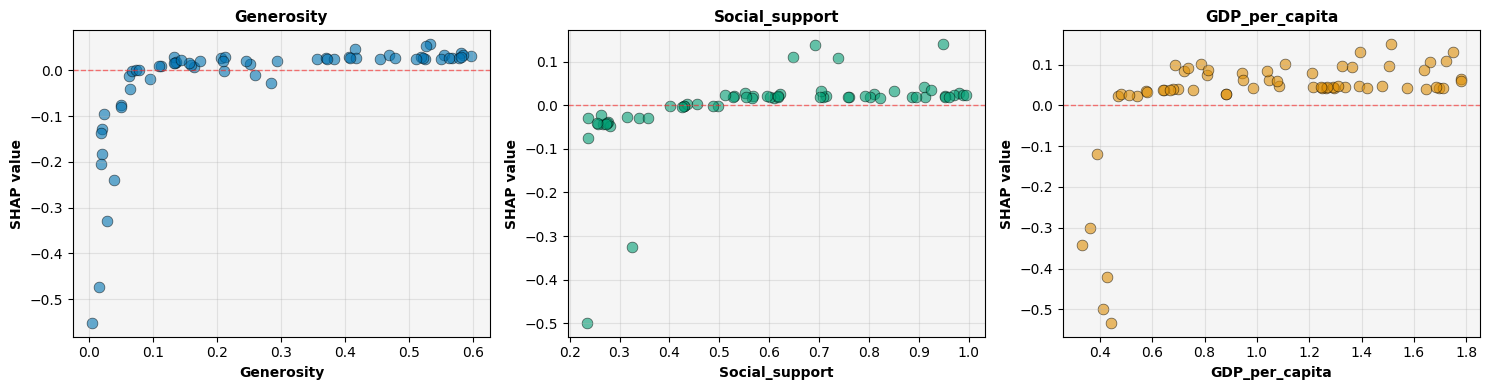

[Figure Saved] 05_shap_dependence.png (Colorblind-Safe)


In [ ]:
# SHAP Dependence Plots (top 3 features) - COLORBLIND-SAFE
top_features_idx = importance_df['Feature'].tail(3).tolist()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# Colorblind-safe palette for consistency
cb_colors = ['#0173B2', '#029E73', '#DE8F05']

for idx, feature in enumerate(top_features_idx):
    feature_idx = feature_names.index(feature)
    # Create dependence plot with colorblind-safe colors
    x_data = X_test[:, feature_idx]
    y_data = shap_values.values[:, feature_idx]
    
    # Scatter plot with colorblind color
    axes[idx].scatter(x_data, y_data, color=cb_colors[idx], alpha=0.6, 
                     edgecolors='black', linewidth=0.5, s=60)
    axes[idx].set_xlabel(feature, fontweight='bold')
    axes[idx].set_ylabel('SHAP value', fontweight='bold')
    axes[idx].set_title(f'{feature}', fontweight='bold', fontsize=11)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].axhline(y=0, color='red', linestyle='--', alpha=0.5, linewidth=1)

plt.tight_layout()
plt.savefig('05_shap_dependence.png', dpi=100, bbox_inches='tight')
plt.show()
print("[Figure Saved] 05_shap_dependence.png (Colorblind-Safe)")

# Section 8: Analyzing Predictions & Errors

## How Good Are Our Predictions?

### Key Metrics

1. **R2 Score** (0 to 1)
   - Fraction of variance explained
   - R2 = 0.95 means model explains 95% of variation

2. **RMSE** (Root Mean Squared Error)
   - Average prediction error in original units
   - Sensitive to outliers

3. **MAE** (Mean Absolute Error)
   - Average absolute prediction error
   - More robust to outliers

### Residual Analysis

Good residuals should:
- Have mean close to 0 (no systematic bias)
- Be normally distributed (bell curve)
- Have similar spread across prediction range
- Have no patterns (no relationships missed)

In [ ]:
print("\n" + "="*70)
print("ANALYZING PREDICTIONS & ERRORS")
print("="*70)

# Residuals
residuals = y_test - y_pred_optimal

print(f"\nRESIDUAL STATISTICS:")
print("-" * 70)
print(f"Mean residual:     {residuals.mean():.4f} (should be ~0)")
print(f"Std dev:           {residuals.std():.4f}")
print(f"Min residual:      {residuals.min():.4f}")
print(f"Max residual:      {residuals.max():.4f}")
print(f"% within 1 RMSE:   {(np.abs(residuals) <= optimal_rmse).mean()*100:.1f}%")


ANALYZING PREDICTIONS & ERRORS

RESIDUAL STATISTICS:
----------------------------------------------------------------------
Mean residual:     0.0802 (should be ~0)
Std dev:           0.2348
Min residual:      -0.5726
Max residual:      0.9996
% within 1 RMSE:   87.3%


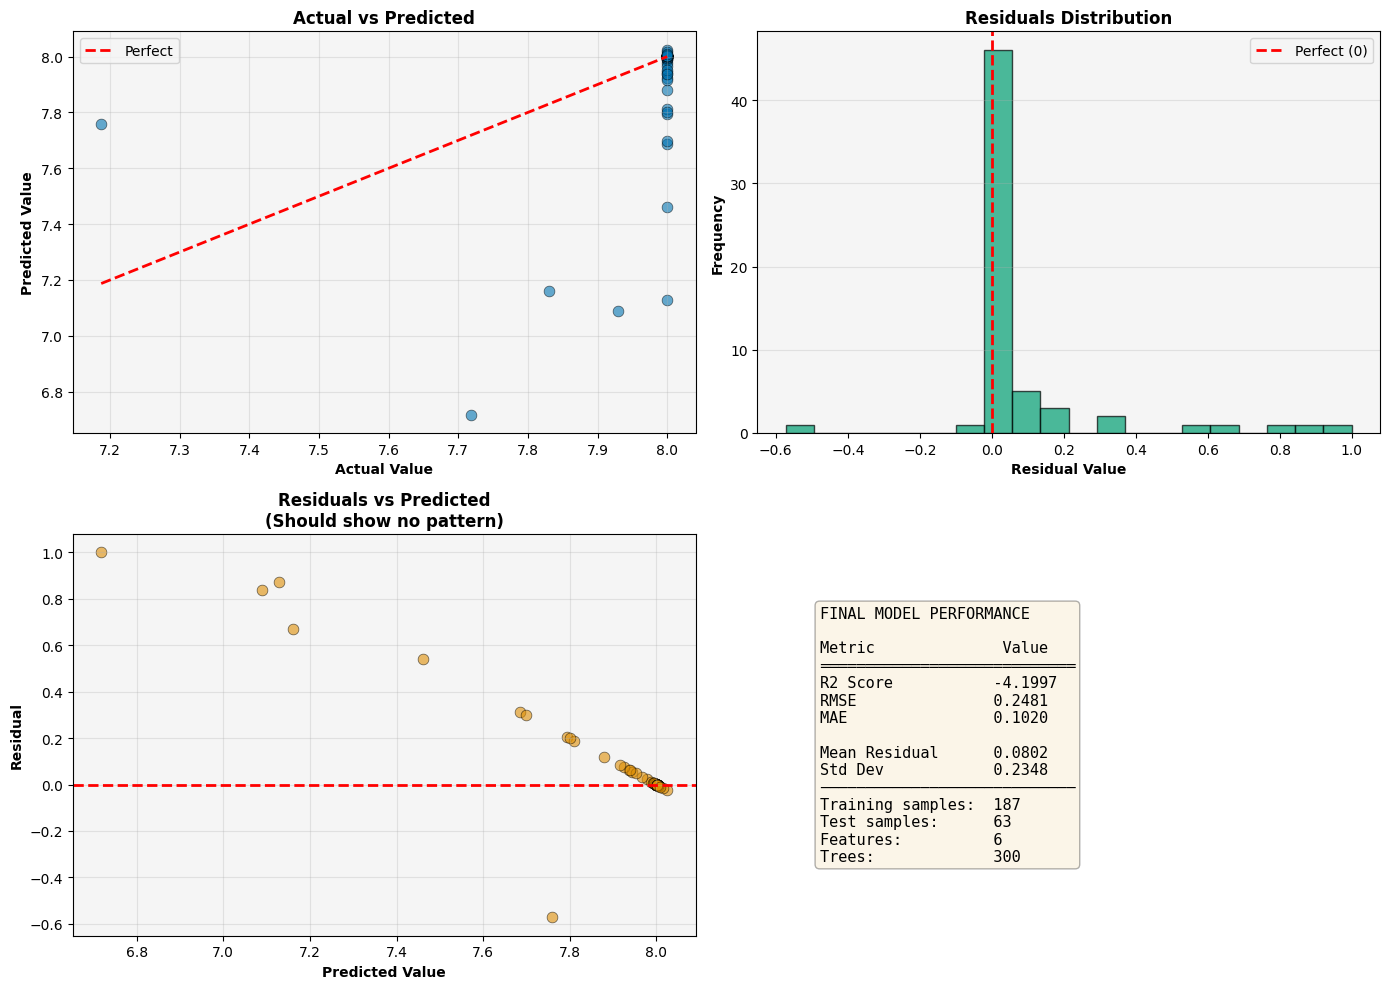

[Figure Saved] 06_prediction_analysis.png


In [ ]:
# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Actual vs Predicted scatter
axes[0, 0].scatter(y_test, y_pred_optimal, alpha=0.6, s=60, color='#0173B2', edgecolor='black', linewidth=0.5)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect')
axes[0, 0].set_xlabel('Actual Value', fontweight='bold')
axes[0, 0].set_ylabel('Predicted Value', fontweight='bold')
axes[0, 0].set_title('Actual vs Predicted', fontweight='bold', fontsize=12)
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Residuals histogram
axes[0, 1].hist(residuals, bins=20, color='#029E73', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(0, color='red', linestyle='--', linewidth=2, label='Perfect (0)')
axes[0, 1].set_xlabel('Residual Value', fontweight='bold')
axes[0, 1].set_ylabel('Frequency', fontweight='bold')
axes[0, 1].set_title('Residuals Distribution', fontweight='bold', fontsize=12)
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# Residuals vs Predicted
axes[1, 0].scatter(y_pred_optimal, residuals, alpha=0.6, s=60, color='#DE8F05', edgecolor='black', linewidth=0.5)
axes[1, 0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Predicted Value', fontweight='bold')
axes[1, 0].set_ylabel('Residual', fontweight='bold')
axes[1, 0].set_title('Residuals vs Predicted\n(Should show no pattern)', fontweight='bold', fontsize=12)
axes[1, 0].grid(alpha=0.3)

# Performance metrics summary
metrics_text = f"""FINAL MODEL PERFORMANCE

Metric              Value
════════════════════════════
R2 Score           {optimal_r2:.4f}
RMSE               {optimal_rmse:.4f}
MAE                {optimal_mae:.4f}

Mean Residual      {residuals.mean():.4f}
Std Dev            {residuals.std():.4f}
────────────────────────────
Training samples:  {len(X_train)}
Test samples:      {len(X_test)}
Features:          {len(feature_names)}
Trees:             {best_params['n_estimators']}"""

axes[1, 1].text(0.1, 0.5, metrics_text, fontfamily='monospace', fontsize=11,
               verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
axes[1, 1].axis('off')

plt.tight_layout()
plt.savefig('06_prediction_analysis.png', dpi=100, bbox_inches='tight')
plt.show()
print("[Figure Saved] 06_prediction_analysis.png")

# Section 9: Best Practices & Summary

## Best Practices for Gradient Boosting

### 1. Start Simple, Then Tune
- Use default parameters first
- Gradually tune hyperparameters
- Don't tune everything at once

### 2. Cross-Validation is Essential
- Always use k-fold cross-validation (k=5 or 10)
- More reliable than single train-test split
- Helps detect overfitting early

### 3. Monitor for Overfitting
- Watch training vs validation error
- If validation error increases, you're overfitting
- Use early stopping if available

### 4. Feature Engineering Helps
- Preprocessing features improves accuracy
- Feature scaling not necessary (trees are scale-invariant)
- Handle missing values before training

### 5. Use Interpretability Tools
- Feature importance for feature selection
- SHAP values for understanding predictions
- Build trust with stakeholders

## When to Use Gradient Boosting

### YES, use GB when:
- You need highest possible accuracy
- You have sufficient training data (>1000 samples)
- Training time is not critical
- Feature interactions exist
- You need interpretability

### NO, use GB when:
- Training time is critical (use Random Forest)
- You have <100 samples
- You need real-time predictions on high-volume data
- Your problem is linear

## Common Pitfalls to Avoid

1. ❌ Tuning on test set → Use cross-validation instead
2. ❌ Not checking overfitting → Monitor learning curves
3. ❌ Ignoring class imbalance → Use sample_weight
4. ❌ Training without preprocessing → Clean data matters
5. ❌ Using default parameters → Tuning matters significantly

In [ ]:
print("\n" + "="*70)
print("BEST PRACTICES & SUMMARY")
print("="*70)

# Final summary table
summary_table = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'AdaBoost', 'GB (Default)', 'GB (Tuned)'],
    'R2 Score': [lr_r2, dt_r2, rf_r2, ab_r2, gb_r2, optimal_r2],
    'RMSE': [lr_rmse, dt_rmse, rf_rmse, ab_rmse, gb_rmse, optimal_rmse],
    'Complexity': ['Very Low', 'Low', 'Medium', 'Medium', 'High', 'High']
})

print("\nFINAL MODEL COMPARISON:")
print("-" * 70)
print(summary_table.to_string(index=False))

print("\n" + "="*70)
print("TUTORIAL COMPLETE - KEY TAKEAWAYS")
print("="*70)

print("\n✓ You now understand:")
print("  1. How Gradient Boosting works sequentially")
print("  2. Why it outperforms simpler algorithms")
print("  3. How to tune hyperparameters systematically")
print("  4. How to interpret models with SHAP")
print("  5. When and how to use Gradient Boosting in practice")

print("\n[All visualizations saved:]")
print("  - 01_algorithm_comparison.png")
print("  - 02_hyperparameter_tuning.png")
print("  - 03_feature_importance.png")
print("  - 04_shap_summary.png")
print("  - 05_shap_dependence.png")
print("  - 06_prediction_analysis.png")

print("\n" + "="*70 + "\n")


BEST PRACTICES & SUMMARY

FINAL MODEL COMPARISON:
----------------------------------------------------------------------
            Model                                                                                                 R2 Score     RMSE Complexity
Linear Regression [-0.3896348586737286, -8.506738169389944, -11.663695505291026, -12.327778726628562, -13.139439738468576] 0.158348   Very Low
    Decision Tree                                                                                                -14.29085 0.425436        Low
    Random Forest                                                                                                -1.655927 0.177307     Medium
         AdaBoost                                                                                                -0.166757 0.117519     Medium
     GB (Default)                                                                                                -4.210865 0.248355       High
       GB (Tuned)   